## Delay Analysis

* This notebook looks at how delays (the dependent variable) vary with the features such as airline, airport to get an idea of which features may be important

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/flight_weather_data_2025.csv")
df.shape

(359999, 32)

In [3]:
df["DELAY"].value_counts(normalize=True)

DELAY
0    0.777688
1    0.222312
Name: proportion, dtype: float64

<Axes: ylabel='AIRLINE'>

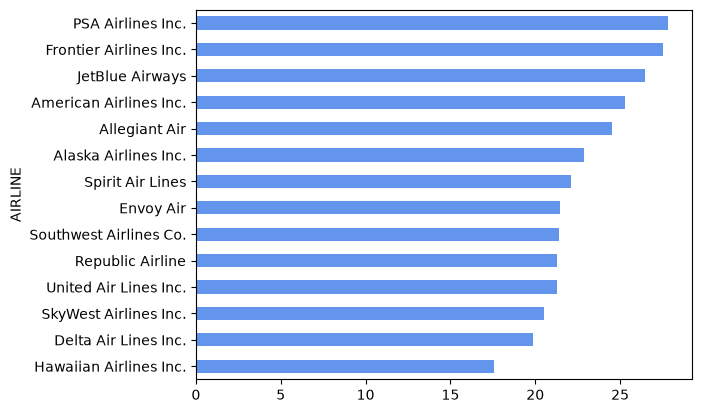

In [12]:
results = df.groupby("AIRLINE").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results["delay_pct"] = round((results["num_delays"] / results["flights"]) * 100, 2)

results.sort_values("delay_pct", ascending=False).sort_values("delay_pct").plot(kind='barh',
                                                                                x='AIRLINE',
                                                                                y='delay_pct',
                                                                                legend=False,
                                                                                color="cornflowerblue")

<Axes: ylabel='MONTH'>

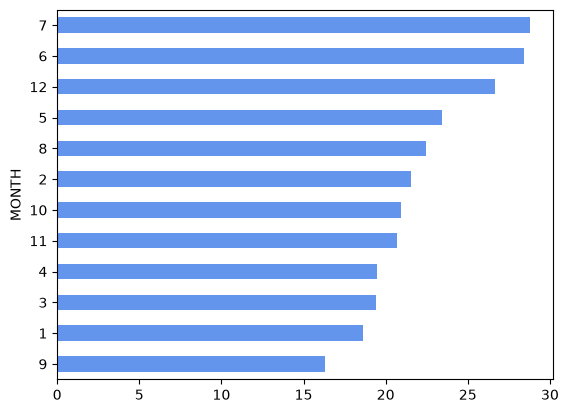

In [13]:
results = df.groupby("MONTH").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results["delay_pct"] = round((results["num_delays"] / results["flights"]) * 100, 2)

results.sort_values("delay_pct", ascending=False).sort_values("delay_pct").plot(kind='barh',
                                                                                x='MONTH',
                                                                                y='delay_pct',
                                                                                legend=False,
                                                                                color="cornflowerblue")

In [15]:
results.sort_values("delay_pct", ascending=False)

,MONTH,flights,num_delays,delay_pct
6,7,30000,8627,28.76
5,6,30000,8519,28.40
11,12,29999,7994,26.65
4,5,30000,7038,23.46
7,8,30000,6743,22.48
1,2,30000,6456,21.52
9,10,30000,6281,20.94
10,11,30000,6211,20.70
3,4,30000,5845,19.48
2,3,30000,5828,19.43


In [ ]:
# june, july, december most delayed

# september, jan, march least delayed 

<Axes: ylabel='DAY_OF_WEEK'>

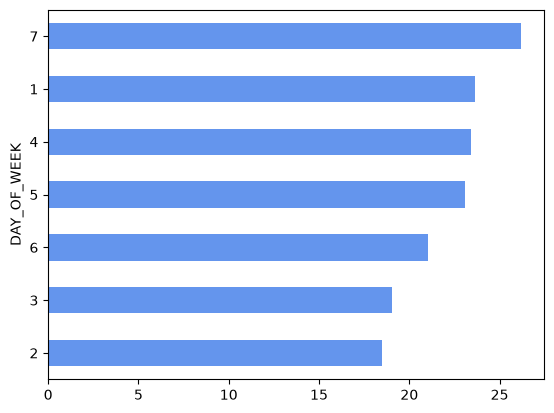

In [18]:
results = df.groupby("DAY_OF_WEEK").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results["delay_pct"] = round((results["num_delays"] / results["flights"]) * 100, 2)

results.sort_values("delay_pct", ascending=False).sort_values("delay_pct").plot(kind='barh',
                                                                                x='DAY_OF_WEEK',
                                                                                y='delay_pct',
                                                                                legend=False,
                                                                                color="cornflowerblue")

In [20]:
results.sort_values("delay_pct", ascending=False)

,DAY_OF_WEEK,flights,num_delays,delay_pct
6,7,53629,14031,26.16
0,1,54261,12835,23.65
3,4,53776,12576,23.39
4,5,53932,12449,23.08
5,6,46520,9780,21.02
2,3,48806,9290,19.03
1,2,49075,9071,18.48


In [33]:
results = df.groupby("DEST").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results["flights"].describe()

count      350.000000
mean      1028.568571
std       2429.345140
min          1.000000
25%         40.250000
50%        138.000000
75%        680.250000
max      16659.000000
Name: flights, dtype: float64

<Axes: ylabel='DEST'>

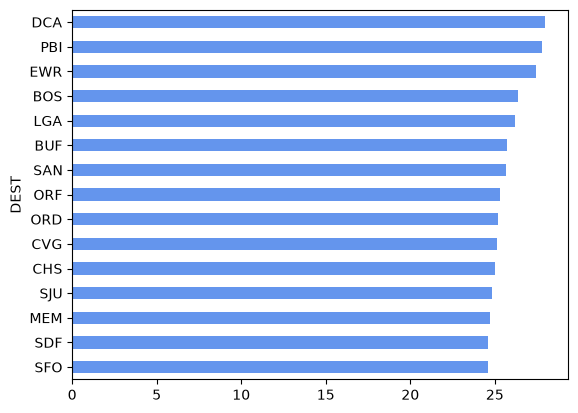

In [36]:
results = df.groupby("DEST").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results = results[results["flights"] > 1000] # filter for large enough sample to get true measure of delay
results["delay_pct"] = round((results["num_delays"] / results["flights"]) * 100, 2)
results = results.sort_values("delay_pct",ascending=False).head(15)

results.sort_values("delay_pct").plot(kind='barh',
                                      x='DEST',
                                      y='delay_pct',
                                      legend=False,
                                      color="cornflowerblue")

In [37]:
results

,DEST,flights,num_delays,delay_pct
86,DCA,7206,2013,27.94
248,PBI,1552,431,27.77
111,EWR,6058,1663,27.45
44,BOS,7282,1921,26.38
195,LGA,6885,1803,26.19
53,BUF,1018,262,25.74
288,SAN,5057,1298,25.67
242,ORF,1012,256,25.30
241,ORD,16659,4191,25.16
80,CVG,1765,443,25.10


<Axes: xlabel='DEP_HOUR'>

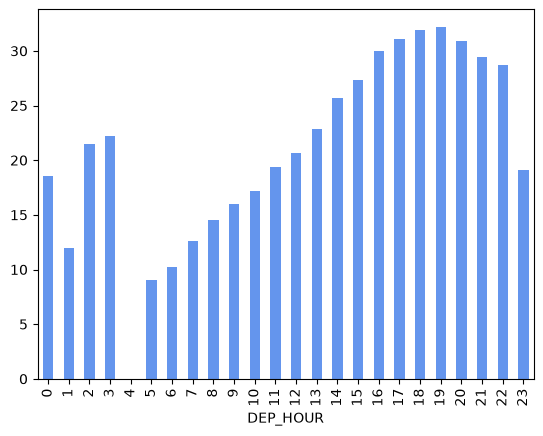

In [71]:
results = df.groupby("DEP_HOUR").agg(flights=("MONTH","size"), num_delays=("DELAY", "sum")).reset_index()
results["delay_pct"] = round((results["num_delays"] / results["flights"]) * 100, 2)
results = results.sort_values("delay_pct",ascending=False)

results.sort_values("DEP_HOUR").plot(kind='bar',
                                      x='DEP_HOUR',
                                      y='delay_pct',
                                      legend=False,
                                      color="cornflowerblue")

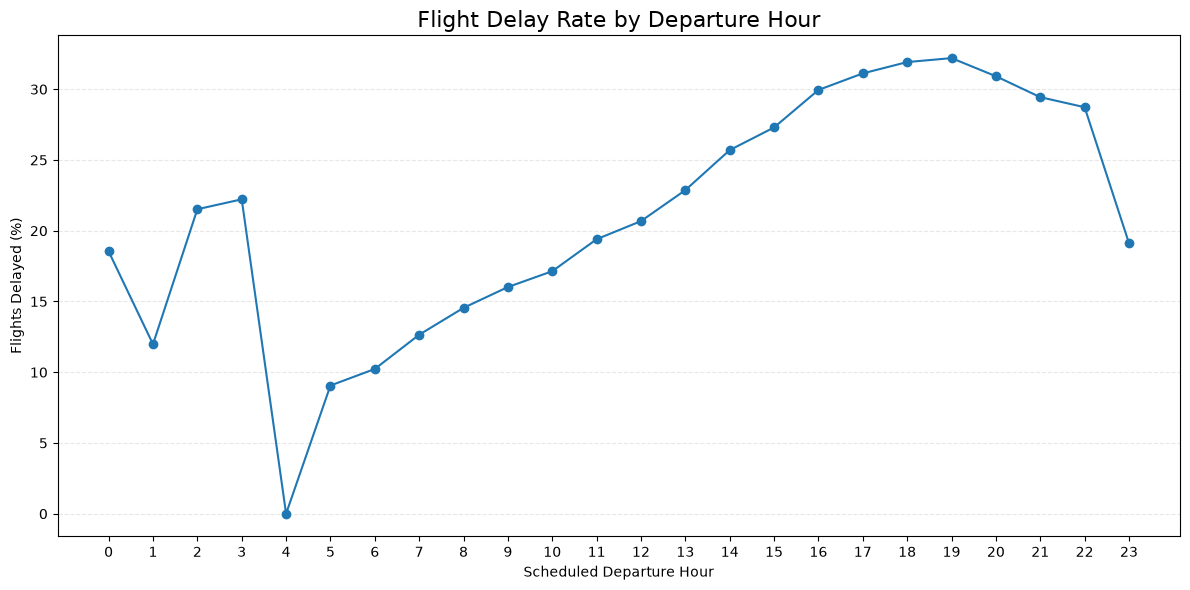

In [77]:
min_flights = 0

results["delay_pct_plot"] = results["delay_pct"].where(
    results["flights"] >= min_flights
)

plt.figure(figsize=(12, 6))

plt.plot(
    results["DEP_HOUR"],
    results["delay_pct_plot"],
    marker="o"
)

plt.title("Flight Delay Rate by Departure Hour", fontsize=16)
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Flights Delayed (%)")

plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [78]:
df["DEP_HOUR"].value_counts().sort_values()

DEP_HOUR
4         9
3        36
2        79
1       167
0       631
23     2845
22     7911
5     10177
21    11989
20    15965
19    19343
9     20309
16    20676
15    20826
14    21100
18    21249
12    21489
13    21667
17    22328
10    22385
11    22759
6     24635
8     24993
7     26431
Name: count, dtype: int64

In [75]:
df["DEP_HOUR"].value_counts().sort_index()

DEP_HOUR
0       631
1       167
2        79
3        36
4         9
5     10177
6     24635
7     26431
8     24993
9     20309
10    22385
11    22759
12    21489
13    21667
14    21100
15    20826
16    20676
17    22328
18    21249
19    19343
20    15965
21    11989
22     7911
23     2845
Name: count, dtype: int64

In [69]:
df["DEP_HOUR"].describe()

count    359999.000000
mean         12.942733
std           4.878337
min           0.000000
25%           9.000000
50%          13.000000
75%          17.000000
max          23.000000
Name: DEP_HOUR, dtype: float64

In [43]:
df["DEP_PRECIPITATION"].describe()

count    359999.000000
mean          0.089769
std           1.563318
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         159.800000
Name: DEP_PRECIPITATION, dtype: float64

In [39]:
# Create precipitation severity groups
df["precip_group"] = pd.cut(
    df["DEP_PRECIPITATION"],   
    bins=[-0.01, 0, 1, 5, float("inf")],
    labels=["None", "Light", "Moderate", "Heavy"]
)

weather_results = (
    df.groupby("precip_group", observed=True)
      .agg(
          flights=("DELAY", "size"),
          num_delays=("DELAY", "sum")
      )
      .reset_index()
)

weather_results["delay_pct"] = (
    weather_results["num_delays"] /
    weather_results["flights"] * 100
).round(2)

weather_results

,precip_group,flights,num_delays,delay_pct
0,None,347217,75461,21.73
1,Light,7866,2510,31.91
2,Moderate,3784,1515,40.04
3,Heavy,1132,546,48.23


In [40]:
print(weather_results)

  precip_group  flights  num_delays  delay_pct
0         None   347217       75461      21.73
1        Light     7866        2510      31.91
2     Moderate     3784        1515      40.04
3        Heavy     1132         546      48.23


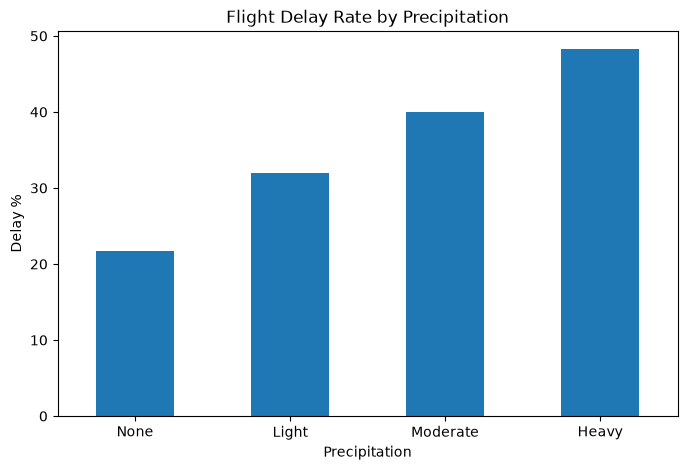

In [42]:
import matplotlib.pyplot as plt 

weather_results.plot(
    kind="bar",
    x="precip_group",
    y="delay_pct",
    legend=False,
    figsize=(8, 5)
)

plt.xlabel("Precipitation")
plt.ylabel("Delay %")
plt.title("Flight Delay Rate by Precipitation")
plt.xticks(rotation=0)
plt.show()

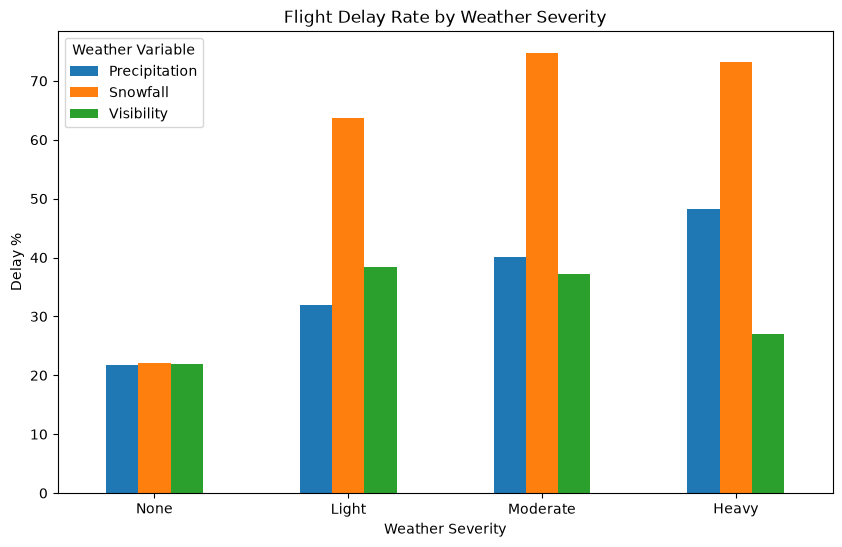

In [64]:
df["precip_severity"] = pd.cut(
    df["DEP_PRECIPITATION"],
    bins=[-0.01, 0, 1, 5, float("inf")],
    labels=["None", "Light", "Moderate", "Heavy"]
)

# Start by treating all observations as no snowfall
df["snow_severity"] = "None"

# Identify observations where snowfall actually occurred
snow_mask = df["DEP_SNOWFALL"] > 0

# Split snowy observations into three roughly equal groups
df.loc[snow_mask, "snow_severity"] = pd.qcut(
    df.loc[snow_mask, "DEP_SNOWFALL"],
    q=3,
    labels=["Light", "Moderate", "Heavy"]
).astype(str)


# Lower visibility = more severe weather
df["visibility_severity"] = pd.cut(
    df["DEP_VISIBILITY"],
    bins=[0, 2000, 5000, 10000, float("inf")],
    labels=["Heavy", "Moderate", "Light", "None"]
)

precip = (
    df.groupby("precip_severity", observed=True)["DELAY"]
      .mean()
      .mul(100)
)


snow = (
    df.groupby("snow_severity", observed=True)["DELAY"]
      .mean()
      .mul(100)
)


visibility = (
    df.groupby("visibility_severity", observed=True)["DELAY"]
      .mean()
      .mul(100)
)

weather_results = pd.DataFrame({
    "Precipitation": precip,
    "Snowfall": snow,
    "Visibility": visibility
})

# Ensure correct severity order
weather_results = weather_results.reindex(
    ["None", "Light", "Moderate", "Heavy"]
)

weather_results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Weather Severity")
plt.ylabel("Delay %")
plt.title("Flight Delay Rate by Weather Severity")
plt.xticks(rotation=0)
plt.legend(title="Weather Variable")
plt.show()